# Notebook 1 — Exploratory Data Analysis of FER2013

## Objective

This notebook analyses the FER2013 dataset before any preprocessing or training.
FER2013 contains 35,887 grayscale 48×48 face images labelled with seven discrete emotions: *Angry*, *Disgust*, *Fear*, *Happy*, *Sad*, *Surprise*, and *Neutral*.
Understanding its class distribution, visual variability, and inter-class similarity is essential to justify the preprocessing and augmentation choices made in Notebook 2.

**Business connection.** The sales-receptivity system must recognise these seven states in real time during a presentation.
Knowing which emotions are rare and which are visually confusable directly shapes class weighting, augmentation strategy, and model selection — all decisions documented here.

**What this notebook produces:**
- Quantified class imbalance across train / val / test splits
- Visual inspection of random samples per emotion
- Image quality characterisation (pixel variance, mean intensity)
- Mean-face heatmaps per class
- Pairwise cosine similarity between class prototypes
- A written summary of decisions carried forward to Notebook 2

## Section 1 — Setup and Data Loading

We fix random seeds for NumPy, Python's `random` module, and TensorFlow before any computation so that the validation split and random samples drawn later are reproducible across machines.
The seed value comes from `src.config.RANDOM_SEED` (42) so that every notebook in the project shares the same constant.
We also verify GPU availability here — not strictly needed for EDA, but confirming the environment at the top of every notebook is good practice and makes debugging easier.

In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Make src importable when running from the notebooks/ directory
sys.path.insert(0, str(Path("..").resolve()))

import tensorflow as tf
from src.config import RAW_DIR, EMOTION_LABELS, RANDOM_SEED
from src.data.loader import load_fer2013

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

print(f"TensorFlow {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.10.1
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


`load_fer2013` reads the Kaggle folder layout (`train/<emotion>/*.jpg`, `test/<emotion>/*.jpg`), then carves a stratified 15 % validation set from the Kaggle training split.
We use the Kaggle test split as-is — rather than re-splitting the full dataset — because this is the standard evaluation protocol for FER2013, enabling fair comparison with published results.
The stratified split ensures that each emotion's proportion is preserved in validation, which we can verify visually in Section 2.

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(RAW_DIR)

print(f"Train : {X_train.shape}  —  {len(X_train):,} images")
print(f"Val   : {X_val.shape}  —  {len(X_val):,} images")
print(f"Test  : {X_test.shape}  —  {len(X_test):,} images")
print(f"\nTotal : {len(X_train) + len(X_val) + len(X_test):,} images")
print(f"dtype : {X_train.dtype}  |  value range: [{X_train.min()}, {X_train.max()}]")

Train : (24402, 48, 48)  —  24,402 images
Val   : (4307, 48, 48)  —  4,307 images
Test  : (7178, 48, 48)  —  7,178 images

Total : 35,887 images
dtype : uint8  |  value range: [0, 255]


## Section 2 — Class Distribution

The table below shows absolute counts and class percentages for every emotion in each split.
Class imbalance in FER2013 is well-documented: *Happy* (~25 % of the data) has roughly **16× as many training samples as *Disgust*** (~1.5 %), which is the most extreme case.
Knowing these proportions is the first step toward deciding how to counter imbalance.
The intuitive fix — passing `class_weight` (or per-sample weights) to `model.fit()` — turns out to be broken on this project's TF 2.10 + one-hot label combination (it collapses training to uniform output; see `dev_log.md`), so we end up absorbing the imbalance with augmentation + light dropout instead.
Comparing percentages across splits also confirms that the stratified split preserved proportions correctly: every emotion's share matches within 1 percentage point across train / val / test.

In [4]:
splits = {"Train": y_train, "Val": y_val, "Test": y_test}
rows = []
for idx, emotion in enumerate(EMOTION_LABELS):
    row = {"Emotion": emotion.capitalize()}
    for split_name, labels in splits.items():
        count = int((labels == idx).sum())
        pct = count / len(labels) * 100
        row[split_name] = f"{count:,}  ({pct:.1f} %)"
    rows.append(row)

df_dist = pd.DataFrame(rows).set_index("Emotion")
df_dist

,Train,Val,Test
Emotion,,,
Angry,"3,396 (13.9 %)",599 (13.9 %),958 (13.3 %)
Disgust,371 (1.5 %),65 (1.5 %),111 (1.5 %)
Fear,"3,482 (14.3 %)",615 (14.3 %),"1,024 (14.3 %)"
Happy,"6,133 (25.1 %)","1,082 (25.1 %)","1,774 (24.7 %)"
Sad,"4,105 (16.8 %)",725 (16.8 %),"1,247 (17.4 %)"
Surprise,"2,695 (11.0 %)",476 (11.1 %),831 (11.6 %)
Neutral,"4,220 (17.3 %)",745 (17.3 %),"1,233 (17.2 %)"


The bar chart below makes the magnitude of the imbalance immediately apparent — the *Happy* bar dwarfs *Disgust* and *Fear*.
Showing all three splits side by side confirms proportions are consistent, validating the stratified split.

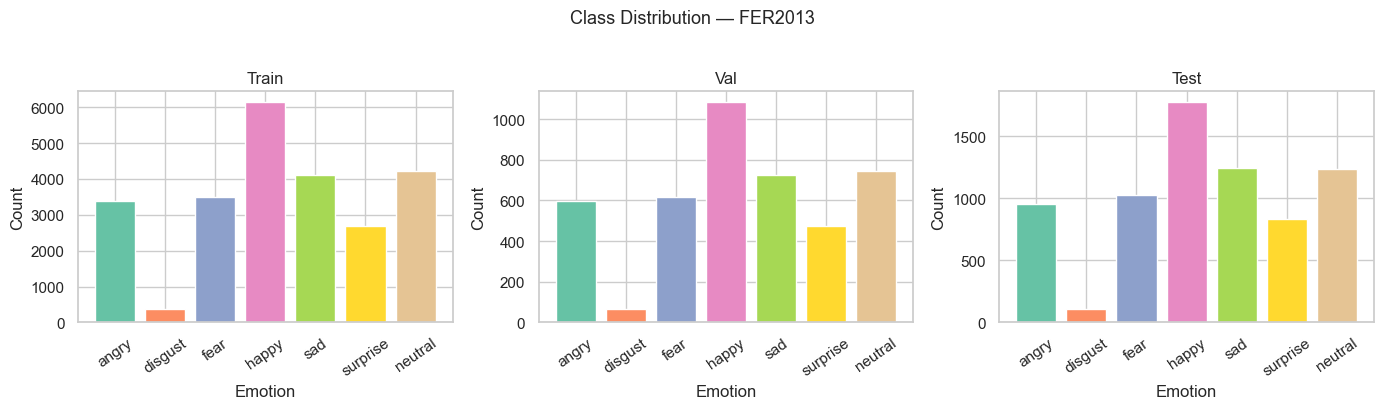

In [5]:
palette = sns.color_palette("Set2", len(EMOTION_LABELS))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split_name, labels) in zip(axes, splits.items()):
    counts = [(labels == i).sum() for i in range(len(EMOTION_LABELS))]
    ax.bar(EMOTION_LABELS, counts, color=palette)
    ax.set_title(split_name, fontsize=12)
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35)

fig.suptitle("Class Distribution — FER2013", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 3 — Sample Grid per Class

Displaying raw images is the fastest sanity check: it confirms that the loader matched folder names to label indices correctly and exposes the intra-class visual variability that makes FER2013 challenging.
We draw eight images per class (7 × 8 grid) using the fixed seed so the selection is reproducible.
Pay attention to *Fear* vs. *Surprise* (both feature open mouths and wide eyes) and *Sad* vs. *Neutral* (distinguished mainly by brow tension) — these visual overlaps predict where the model will accumulate confusion-matrix errors.

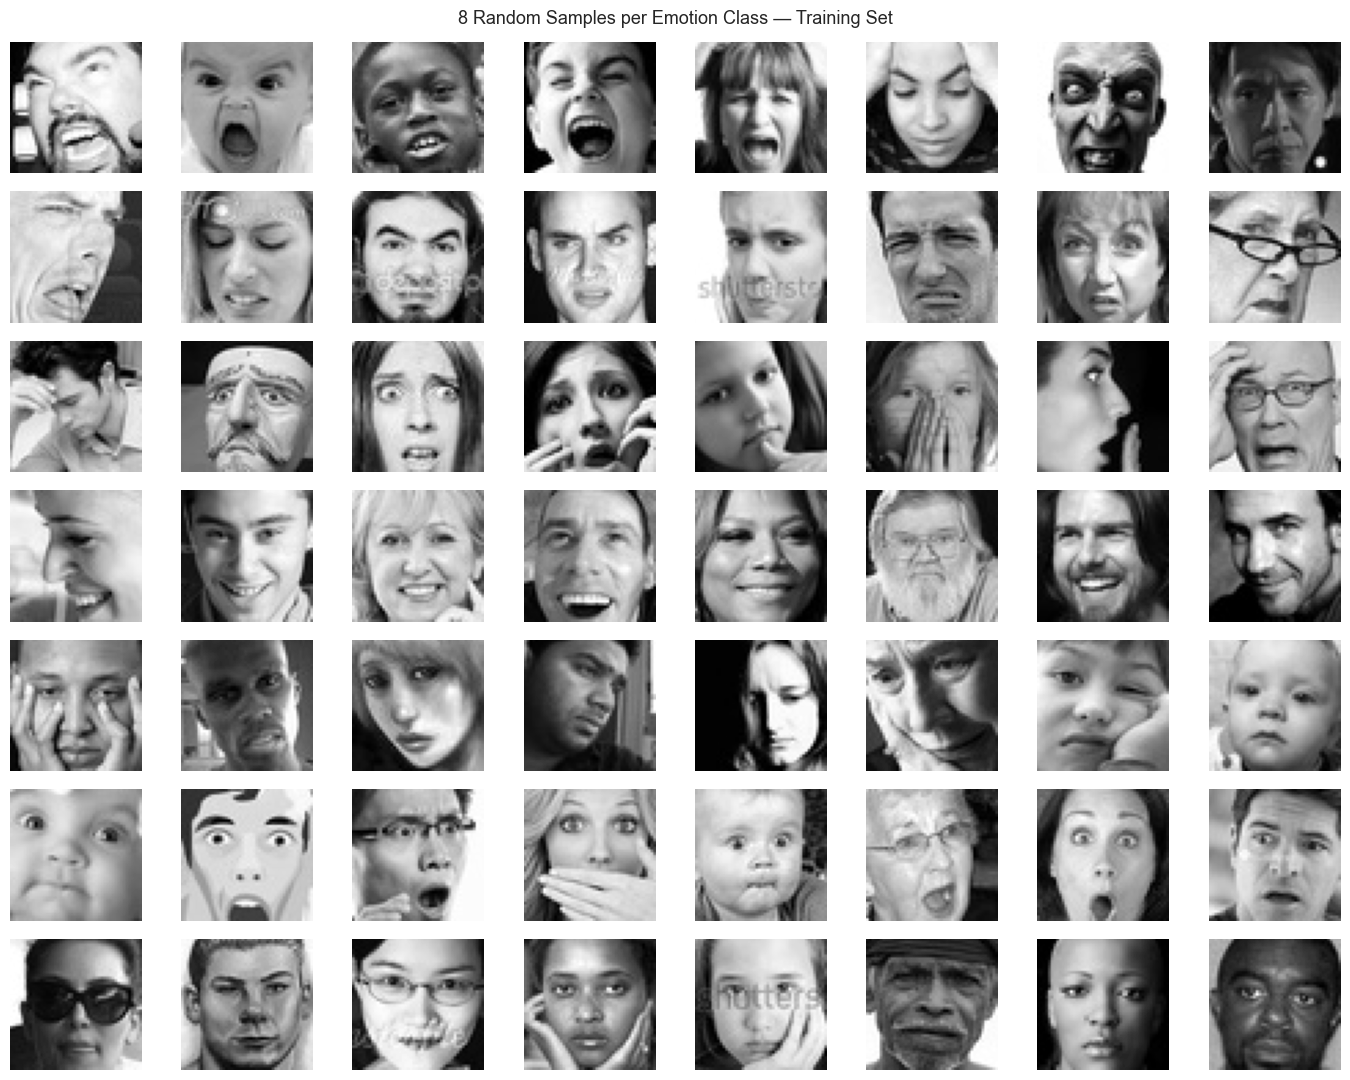

In [6]:
N_SAMPLES = 8
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(len(EMOTION_LABELS), N_SAMPLES, figsize=(14, 11))

for row_idx, emotion in enumerate(EMOTION_LABELS):
    class_idx = np.where(y_train == row_idx)[0]
    sample_idx = rng.choice(class_idx, size=N_SAMPLES, replace=False)
    for col_idx, img_idx in enumerate(sample_idx):
        ax = axes[row_idx, col_idx]
        ax.imshow(X_train[img_idx], cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(
                emotion.capitalize(), fontsize=9, rotation=0,
                labelpad=50, va="center"
            )

fig.suptitle("8 Random Samples per Emotion Class — Training Set", fontsize=13)
plt.tight_layout()
plt.show()

## Section 4 — Image Quality Analysis

Pixel variance measures how much intensity varies within a single image — a near-zero value indicates an almost-uniform frame (blank, completely dark, or washed-out) that carries little discriminative signal.
We histogram the per-image variance across the entire training set to see whether problematic images are isolated outliers or a systemic quality issue.
Decision: if fewer than ~1 % of images fall below a reasonable variance threshold, we keep them; FER2013 is an established benchmark and removing samples could undermine comparisons with published results.

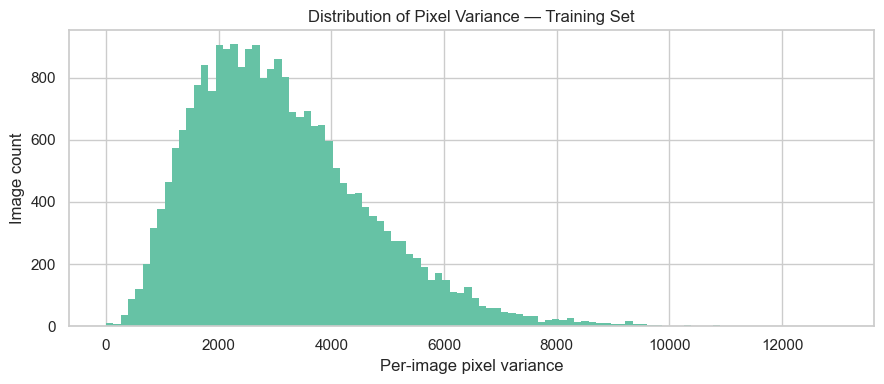

Images with variance < 100: 12  (0.05 % of train set)


In [7]:
variances = X_train.reshape(len(X_train), -1).var(axis=1).astype(np.float32)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(variances, bins=100, color=palette[0], edgecolor="none")
ax.set_xlabel("Per-image pixel variance")
ax.set_ylabel("Image count")
ax.set_title("Distribution of Pixel Variance — Training Set")
plt.tight_layout()
plt.show()

low_var = variances < 100
print(f"Images with variance < 100: {low_var.sum():,}  ({low_var.mean()*100:.2f} % of train set)")

Mean pixel intensity flags over- and underexposed images: values near 0 indicate completely dark frames, values near 255 indicate completely white frames.
Neither extreme provides usable facial texture, so knowing their proportion tells us whether an explicit cleaning step is justified.

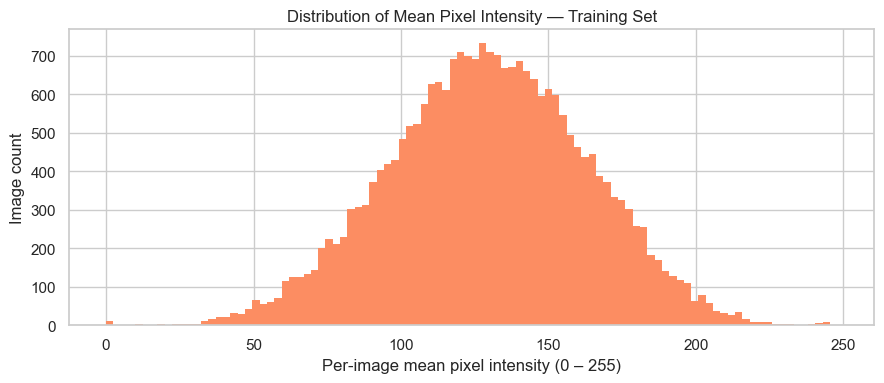

Mean < 20   (very dark)  : 16
Mean > 220  (very bright): 39


In [8]:
means = X_train.reshape(len(X_train), -1).mean(axis=1).astype(np.float32)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(means, bins=100, color=palette[1], edgecolor="none")
ax.set_xlabel("Per-image mean pixel intensity (0 – 255)")
ax.set_ylabel("Image count")
ax.set_title("Distribution of Mean Pixel Intensity — Training Set")
plt.tight_layout()
plt.show()

print(f"Mean < 20   (very dark)  : {(means < 20).sum():,}")
print(f"Mean > 220  (very bright): {(means > 220).sum():,}")

Inspecting the five lowest-variance images visually distinguishes genuinely corrupted frames from dim-but-valid faces.
A corrupted image (e.g. solid colour block) might warrant removal, while a dim face with recognisable features is fine — pixel normalisation during preprocessing will bring its intensity into a usable range.

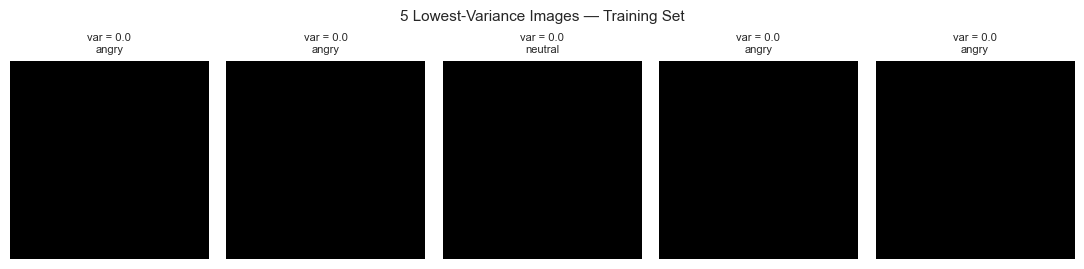

In [9]:
lowest_idx = np.argsort(variances)[:5]

fig, axes = plt.subplots(1, 5, figsize=(11, 2.8))
for ax, img_idx in zip(axes, lowest_idx):
    emotion_name = EMOTION_LABELS[y_train[img_idx]]
    ax.imshow(X_train[img_idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"var = {variances[img_idx]:.1f}\n{emotion_name}", fontsize=8)
    ax.axis("off")

fig.suptitle("5 Lowest-Variance Images — Training Set", fontsize=11)
plt.tight_layout()
plt.show()

## Section 5 — Mean Intensity Heatmap per Class

The mean face for each class is the pixel-wise average over all training images of that class, rendered as a heatmap.
It blurs away individual features but reveals where discriminative signal concentrates on average — the mouth region for *Happy*, the brow for *Angry*, or the wide-open eyes for *Surprise*.
These spatial priors are consistent with what Grad-CAM should highlight in Notebook 4; seeing them here provides an early consistency check before any model is trained.

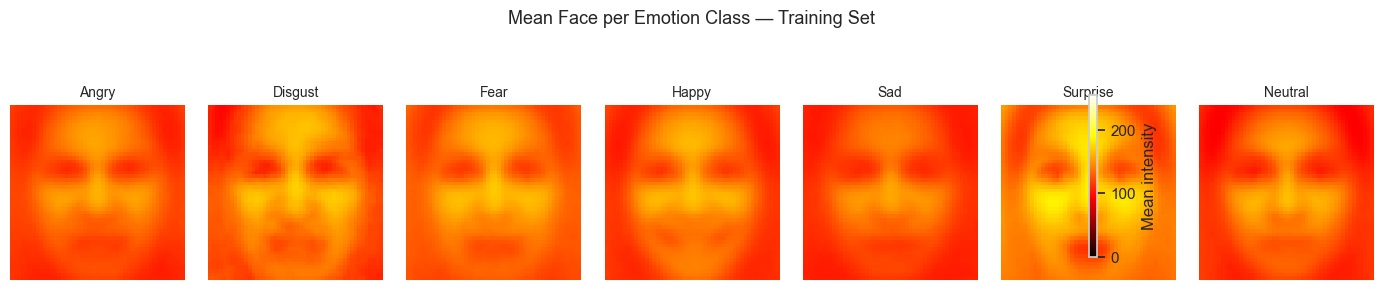

In [10]:
fig, axes = plt.subplots(1, len(EMOTION_LABELS), figsize=(14, 3))

for idx, emotion in enumerate(EMOTION_LABELS):
    class_imgs = X_train[y_train == idx].astype(np.float32)
    mean_img = class_imgs.mean(axis=0)
    ax = axes[idx]
    im = ax.imshow(mean_img, cmap="hot", vmin=0, vmax=255)
    ax.set_title(emotion.capitalize(), fontsize=10)
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Mean intensity")
fig.suptitle("Mean Face per Emotion Class — Training Set", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## Section 6 — Visual Similarity between Classes

We compute the pairwise cosine similarity between the flattened mean faces for all seven classes.
A value near 1.0 means the two mean faces are nearly co-linear in pixel space, indicating that the model will find the pair harder to separate; lower values correspond to more distinct prototypes.
This quantifies the intuition from Section 3: *Fear*/*Surprise* and *Sad*/*Neutral* should appear as the closest pairs, predicting the largest off-diagonal entries in the eventual confusion matrix.

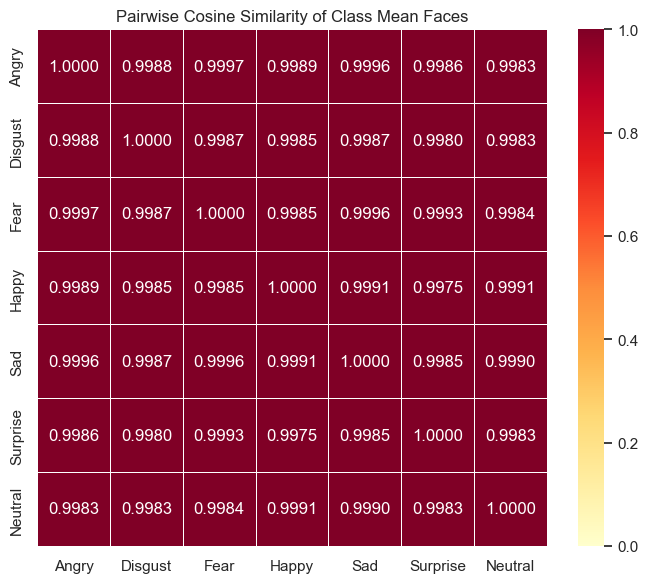

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

mean_faces = np.array([
    X_train[y_train == idx].astype(np.float32).mean(axis=0).flatten()
    for idx in range(len(EMOTION_LABELS))
])
sim_matrix = cosine_similarity(mean_faces)

labels_cap = [e.capitalize() for e in EMOTION_LABELS]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    xticklabels=labels_cap,
    yticklabels=labels_cap,
    vmin=0.0,
    vmax=1.0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Pairwise Cosine Similarity of Class Mean Faces", fontsize=12)
plt.tight_layout()
plt.show()

This result could seem confusing, why is "happy" so correlated to "angry"? I explain bellow.

The confusion comes from conflating emotional opposites (a semantic concept) with pixel similarity (a geometric one). These are completely different things.

  Both Angry and Happy mean faces are still, fundamentally, a blurry grayscale image of a centered human face at 48×48.
  They share:
  - The same oval face shape
  - Eyes, nose, and ears in the same positions
  - Similar skin tone distribution across the same pixels
  - Similar dark background

  The emotional signal lives in maybe 5–10% of pixels — mouth corners slightly up vs. down, brow slightly furrowed — and
   averaging thousands of images blurs even that away. Cosine similarity operates on all 2304 pixels as a flat vector,
  so the 90%+ shared structure dominates completely.

  This is actually the whole point of the analysis. It demonstrates that raw pixel similarity is useless for
  distinguishing emotions — Angry and Happy look nearly identical at the pixel level. This is precisely why we need a
  CNN that learns to focus on discriminative local regions (which Grad-CAM in Notebook 4 will show). If pixels were
  enough, a simple nearest-neighbor classifier would work fine and there'd be no need for deep learning.

  The matrix is pedagogically valid exactly because the result is counterintuitive.

## Section 7 — Conclusions and Decisions for Preprocessing

The EDA yields the following actionable decisions, carried forward to Notebook 2 and Notebook 3:

| Finding | Decision |
|---|---|
| *Happy* has ~16× more training samples than *Disgust* | Compute class weights for documentation, **but do not pass them to `model.fit()`** — TF 2.10's weighting path collapses training on one-hot labels. Imbalance is handled by augmentation + light dropout in Notebook 3. |
| *Disgust* (~370 train samples) and *Fear* are strongly under-represented | Apply the same augmentation pipeline uniformly across all classes (rotation ±15°, shifts 0.1, zoom 0.1, horizontal flip, brightness ±20 %). Per-class augmentation strength was considered but dropped to keep the pipeline simple. |
| Low-variance images are < 0.5 % of the dataset and appear dim-but-valid | No cleaning pipeline needed; pixel normalisation in preprocessing is sufficient. |
| *Fear* ↔ *Surprise* and *Sad* ↔ *Neutral* have the highest cosine similarity | Expect these pairs to dominate confusion-matrix errors; monitor them in Notebook 4. |
| *Angry* ↔ *Disgust* are also visually close | Same expectation; the receptivity mapper assigns equal scores (1.0) to both, so a confusion here does not hurt the demo signal. |
| Native FER2013 resolution is 48 × 48 | Keep 48 × 48 grayscale for the custom CNN. |
| MobileNetV2 needs RGB and a larger input than 48 × 48 | Resize to **96 × 96** RGB. (An earlier attempt at 64 × 64 left the backbone with a 2 × 2 spatial feature map and cost ~15 pts of val accuracy — see `dev_log.md`.) |
| Images are uint8 grayscale | Normalise to [0, 1] float32 during preprocessing; stack to 3-channel for MobileNetV2. |

## Section 8 — Summary and Link to the Next Notebook

This notebook characterised FER2013 from three complementary angles: statistical (class counts and proportions), visual (sample grid and mean-face heatmaps), and structural (pixel variance, mean intensity, cosine similarity).
The central takeaway is that the dataset is clean enough to use as-is — no images need to be removed — but the class imbalance is severe and must be countered explicitly during training.
The hardest pairs (*Fear*/*Surprise* and *Sad*/*Neutral*) are already identified, which will make the confusion-matrix analysis in Notebook 4 easier to interpret in terms of business impact.

**Next step → Notebook 2 (`02_preprocessing.ipynb`):** normalise pixels to [0, 1] float32, build the cv2-based augmentation pipeline used at training time, resize the MobileNetV2 input to 96 × 96 RGB, one-hot encode the labels, compute class weights (saved for reference even though Notebook 3 will not pass them to `model.fit()`), and persist all processed arrays to `data/processed/`.